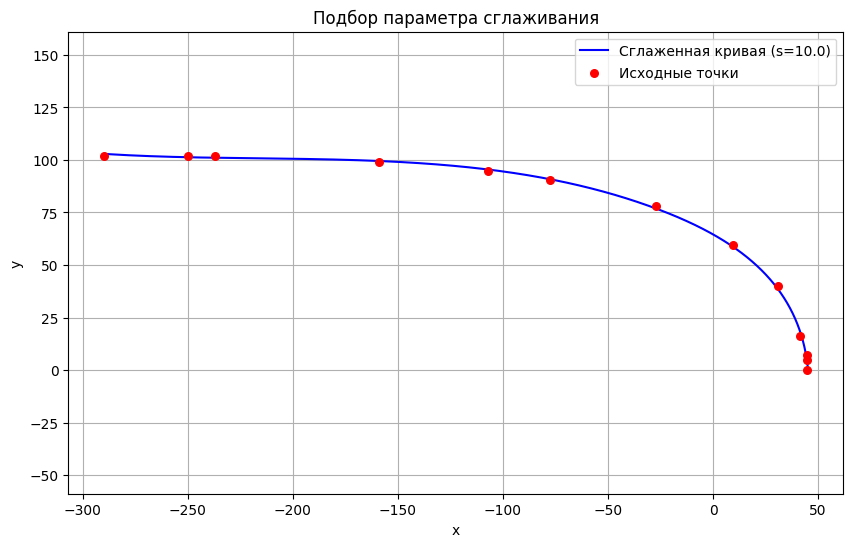

In [13]:
import numpy as np
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt

# Исходные точки (x, y)
# Загрузка точек из файла TS.txt
points = np.loadtxt('HP.txt')          # файл с координатами x y

# ⚙️ Параметр сглаживания (чем больше, тем сильнее сглаживание)
# s = 0.0 → точная интерполяция через все точки
# s > 0 → допустимая сумма квадратов отклонений (можно менять)
smooth_value = 10.0   # попробуйте 1e-5, 1e-4, 0.01, 0.1 и т.д.

# Построение сглаженной параметрической кривой
tck, u = splprep(points.T, s=smooth_value, k=3)

# Генерация плотной сетки точек вдоль кривой
n_dense = 5000
u_dense = np.linspace(0, 1, n_dense)
x_dense, y_dense = splev(u_dense, tck)

# Сортировка по полярному углу
angles = np.arctan2(y_dense, x_dense)
sort_idx = np.argsort(angles)
x_sorted = x_dense[sort_idx]
y_sorted = y_dense[sort_idx]

# Запись в файл
np.savetxt('HP_.txt', np.column_stack((x_sorted, y_sorted)),
           fmt='%.6f', comments='')

# Визуализация с исходными точками
plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_dense, 'b-', label=f'Сглаженная кривая (s={smooth_value})')
plt.scatter(points[:,0], points[:,1], c='red', s=30, zorder=5, label='Исходные точки')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.title('Подбор параметра сглаживания')
plt.show()